In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
df = pd.read_csv(r"C:\Users\Hamza Computerz\Downloads\titanic_dataset.csv")

In [3]:
print("Shape:", df.shape)

Shape: (100000, 31)


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Rows: 100000
Columns: 31

Column names:
['passenger_id', 'full_name', 'age', 'gender', 'nationality', 'marital_status', 'occupation', 'class', 'ticket_number', 'ticket_price', 'cabin_deck', 'embarkation_port', 'travel_purpose', 'journey_duration_days', 'siblings_spouses', 'parents_children', 'family_size', 'is_alone', 'family_survival_rate', 'boarding_position', 'lifeboat_access', 'medical_condition', 'mobility_score', 'emergency_response_time', 'evacuation_priority', 'wealth_index', 'age_group', 'fare_per_person', 'family_risk_score', 'survival_probability', 'survived']


In [5]:
df.head()

,passenger_id,full_name,age,gender,nationality,marital_status,occupation,class,ticket_number,ticket_price,...,medical_condition,mobility_score,emergency_response_time,evacuation_priority,wealth_index,age_group,fare_per_person,family_risk_score,survival_probability,survived
0,T2-000001,Michael Williams,65.3,Male,UK,Single,Student,3,877714,262.18,...,NaN,66.6,6.9,Low,0.55,Senior,87.39,0.92,0.2395,0
1,T2-000002,Mateo Lopez,66.5,Female,France,Married,Tech,3,732611,126.18,...,NaN,66.6,4.0,High,0.24,Senior,126.18,0.60,0.3392,1
2,T2-000003,Joseph Miller,22.4,Female,Australia,Married,Engineering,3,229194,97.53,...,NaN,83.9,24.5,High,0.30,Adult,32.51,1.01,0.0609,0
3,T2-000004,David Garcia,37.1,Male,UK,Married,Military,3,548357,186.24,...,NaN,82.7,15.0,Low,0.79,Middle_Aged,93.12,0.79,0.0279,0
4,T2-000005,Linda Ali,27.8,Male,USA,Married,Student,2,252609,697.00,...,NaN,86.8,5.8,Low,1.44,Adult,232.33,1.06,0.6045,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   passenger_id             100000 non-null  object 
 1   full_name                100000 non-null  object 
 2   age                      100000 non-null  float64
 3   gender                   100000 non-null  object 
 4   nationality              100000 non-null  object 
 5   marital_status           100000 non-null  object 
 6   occupation               91838 non-null   object 
 7   class                    100000 non-null  int64  
 8   ticket_number            100000 non-null  int64  
 9   ticket_price             100000 non-null  float64
 10  cabin_deck               82000 non-null   object 
 11  embarkation_port         100000 non-null  object 
 12  travel_purpose           100000 non-null  object 
 13  journey_duration_days    100000 non-null  int64  
 14  sibli

In [7]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]     .sort_values("Missing Values", ascending=False)

print("Columns containing missing values:")
display(missing_summary)

Columns containing missing values:


,Missing Values,Missing Percentage
medical_condition,74952,74.95
cabin_deck,18000,18.00
occupation,8162,8.16
emergency_response_time,5000,5.00


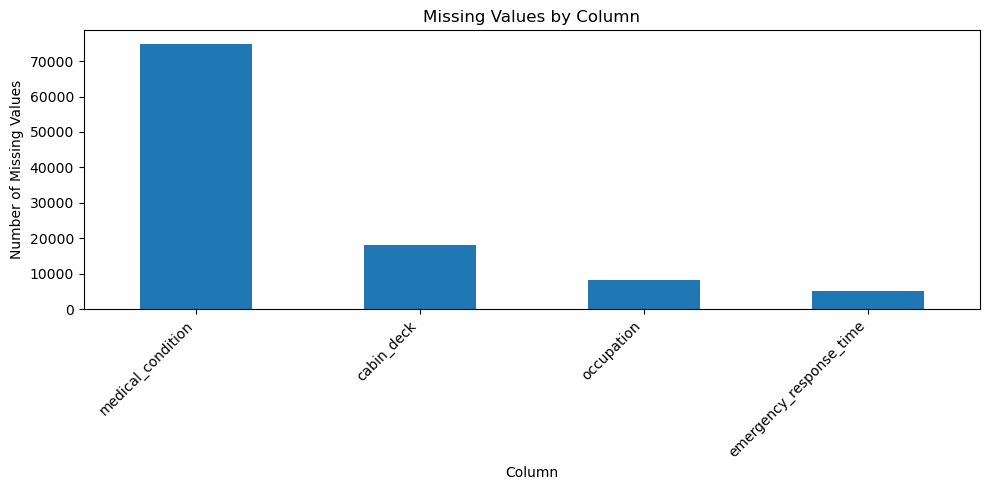

In [8]:
if not missing_summary.empty:
    plt.figure(figsize=(10, 5))
    missing_summary["Missing Values"].plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [9]:
duplicate_count = df.duplicated().sum()

In [10]:
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
df= df.drop_duplicates().copy()

In [12]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (100000, 31)


In [13]:
print("Data types before cleaning:")

Data types before cleaning:


In [14]:
display(df.dtypes)

passenger_id                object
full_name                   object
age                        float64
gender                      object
nationality                 object
marital_status              object
occupation                  object
class                        int64
ticket_number                int64
ticket_price               float64
cabin_deck                  object
embarkation_port            object
travel_purpose              object
journey_duration_days        int64
siblings_spouses             int64
parents_children             int64
family_size                  int64
is_alone                     int64
family_survival_rate       float64
boarding_position            int64
lifeboat_access            float64
medical_condition           object
mobility_score             float64
emergency_response_time    float64
evacuation_priority         object
wealth_index               float64
age_group                   object
fare_per_person            float64
family_risk_score   

In [15]:
date_candidates = [c for c in df.columns if c.lower() in ["date", "datetime"]]

In [16]:
for col in date_candidates:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("\nData types after date validation:")
display(df.dtypes)


Data types after date validation:


passenger_id                object
full_name                   object
age                        float64
gender                      object
nationality                 object
marital_status              object
occupation                  object
class                        int64
ticket_number                int64
ticket_price               float64
cabin_deck                  object
embarkation_port            object
travel_purpose              object
journey_duration_days        int64
siblings_spouses             int64
parents_children             int64
family_size                  int64
is_alone                     int64
family_survival_rate       float64
boarding_position            int64
lifeboat_access            float64
medical_condition           object
mobility_score             float64
emergency_response_time    float64
evacuation_priority         object
wealth_index               float64
age_group                   object
fare_per_person            float64
family_risk_score   

In [17]:
categorical_cols = df.select_dtypes(include=["object", "category", "string"]).columns
numeric_cols = df.select_dtypes(include=np.number).columns

In [18]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


In [19]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- passenger_id ---
passenger_id
T2-099984    1
T2-099983    1
T2-099982    1
T2-099981    1
T2-099980    1
T2-099979    1
T2-099978    1
T2-099977    1
T2-099976    1
T2-099975    1
T2-099974    1
T2-099973    1
T2-099972    1
T2-099971    1
T2-099970    1
Name: count, dtype: int64

--- full_name ---
full_name
Wei Chen              214
Lars Smith            212
Fatima Chen           211
William Johnson       207
Richard Sato          205
Lars Williams         204
Elena Chen            204
Richard Wilson        201
Barbara Garcia        201
Elizabeth Anderson    200
Michael Kim           199
Jessica Silva         199
Elena Brown           198
Richard Lopez         198
Richard Miller        197
Name: count, dtype: int64

--- gender ---
gender
Male          49985
Female        48037
Non-Binary     1978
Name: count, dtype: int64

--- nationality ---
nationality
USA          24793
UK           19998
France       10136
Germany      10082
China         8031
Canada        7908
India        

In [20]:
negative_summary = {}

for col in numeric_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_summary[col] = int(count)

if negative_summary:
    print("Negative values found:")
    print(negative_summary)
else:
    print("No negative values found in numerical columns.")

Negative values found:
{'wealth_index': 13552}


In [21]:
outlier_rows = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_rows.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count)
    })


In [22]:
outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "Outlier Count", ascending=False)

In [23]:
display(outlier_summary)

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
14,wealth_index,0.1100,0.9700,-1.18000,2.260000e+00,12733
15,fare_per_person,65.8375,250.5975,-211.30250,5.277375e+02,10835
3,ticket_price,139.1200,471.5900,-359.58500,9.702950e+02,10546
12,mobility_score,70.7000,88.0000,44.75000,1.139500e+02,3823
13,emergency_response_time,11.9000,31.4000,-17.35000,6.065000e+01,3689
0,age,21.3000,45.1000,-14.40000,8.080000e+01,2352
5,siblings_spouses,0.0000,1.0000,-1.50000,2.500000e+00,2279
6,parents_children,0.0000,1.0000,-1.50000,2.500000e+00,1438
17,survival_probability,0.1111,0.4174,-0.34835,8.768500e-01,740
16,family_risk_score,0.5900,0.9200,0.09500,1.415000e+00,486


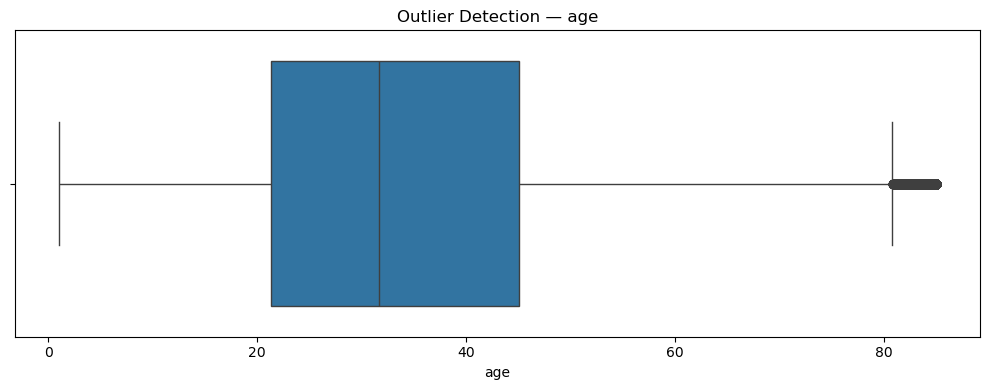

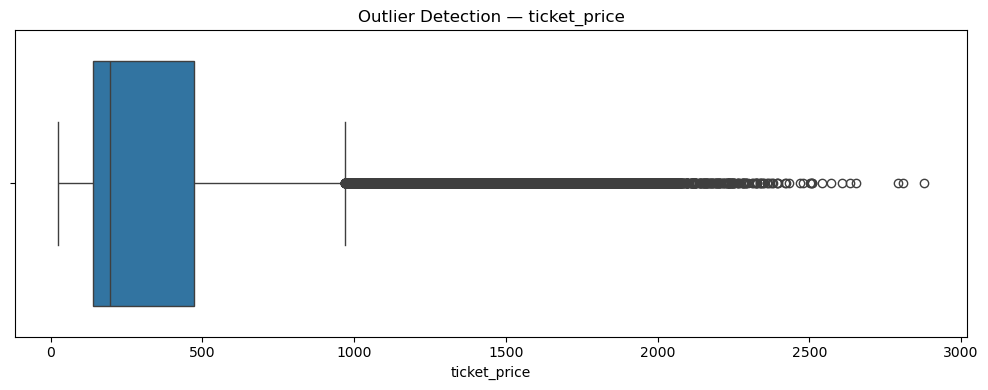

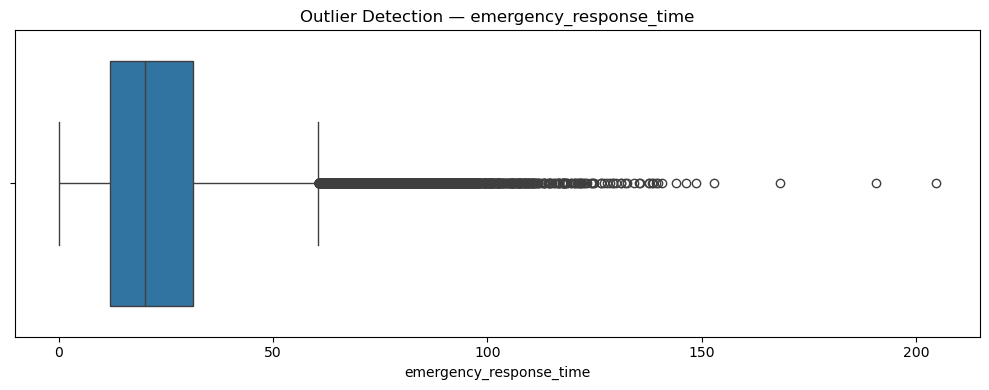

In [24]:
preferred_boxplots = [
    col for col in ["age", "ticket_price", "fare", "emergency_response_time"]
    if col in df.columns
]

if preferred_boxplots:
    for col in preferred_boxplots:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Outlier Detection — {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()
else:
    print("No preferred numeric Titanic columns were found for boxplots.")

In [25]:
if "passenger_id" in df.columns:
    print("Total rows:", len(df))
    print("Unique passenger IDs:", df["passenger_id"].nunique())

for target in ["survived", "Survived"]:
    if target in df.columns:
        print(f"\n{target} value counts:")
        print(df[target].value_counts(dropna=False))
        print(f"\n{target} percentages:")
        print((df[target].value_counts(normalize=True, dropna=False) * 100).round(2))

Total rows: 100000
Unique passenger IDs: 100000

survived value counts:
survived
0    71478
1    28522
Name: count, dtype: int64

survived percentages:
survived
0    71.48
1    28.52
Name: proportion, dtype: float64


In [26]:
print("Final Rows:", df.shape[0])
print("Final Columns:", df.shape[1])

Final Rows: 100000
Final Columns: 31


In [27]:
print("Total Missing Values:", int(df.isnull().sum().sum()))
print("Duplicate Rows:", int(df.duplicated().sum()))

Total Missing Values: 0
Duplicate Rows: 0


In [28]:
assert df.isnull().sum().sum() == 0
assert df.duplicated().sum() == 0

print("All final data-cleaning checks passed!")

All final data-cleaning checks passed!


In [29]:
OUTPUT_FILE = Path("titanic_cleaned.csv")
df.to_csv(OUTPUT_FILE, index=False)

In [30]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [31]:
print("Output file:", OUTPUT_FILE.resolve())

Output file: C:\Users\Hamza Computerz\titanic_cleaned.csv
